# Proyecto Integrador: Predictor de demanda para redes eléctricas

## Comprensión del negocio

En este bloque se explora a grandes rasgos los objetivos, fuentes, preparaciones pertinentes y evaluaciones que se realizarán a lo largo del proyecto.

| Bloque | Fase | Descripción |
| --- | --- | --- |
| Objetivo del negocio | Negocio | Predecir la demanda energética para optimizar el uso de fuentes renovables. |
| Valor del proyecto | Negocio | - **Económico:** Optimización de costes de infraestructura, venta de posibles excedentes de energía y menor dependencia de combustibles fósiles. <br><br> - **Medio ambiente:** Reducción en la contaminación del medio ambiente mediante el uso de fuentes renovables. |
| Fuentes de datos | Datos | - **API Entso-E (En lugar de REE, que no daban API key):** API con datos de las redes eléctricas de Europa públicos. https://www.entsoe.eu/ <br><br> - **Historial Climático:** Archivo excel con el histórico del clima publicado por la AEMET desde el 2013 hasta la actualidad. https://datosclima.es/Aemet2013/DescargaDatos.html <br><br> - **Calendario Laboral y Festivos:** Librería `holidays` para detectar cuando una fecha es festiva o no en la región. Fichero csv con el calendario de festividades por regiones en su defecto. <br><br> - **Precio diario del Mercado:** A través de la API de Red Eléctrica para predecir con mayor exactitud los precios en función de la demanda y la disponibilidad de energía renovable. |
| Variable objetivo | Datos | **Numérica:** Predicción de consumo para un día determinado en MW. |
| Calidad y riesgos | Datos | - **Calidad:** Pueden existir valores no válidos en los datos obtenidos por la API o el historial climático. <br><br> **Riesgos:** La demanda energética puede depende del calendario (festivos, fines de semana, vacaciones, estaciones...). |
| Preparación y features | Preparación | - Limpieza de datos (filtrado de outliers y nulos, transformaciones, etc.). <br><br> - Creación de variables temporales: `es_festivo`. <br><br> - Inclusión de datos históricos de España desde el 2013 como predictores. <br><br> - Arquitectura de datos con AWS S3 para capas bronce, plata y oro, AWS Lambda y procesamiento local con Pandas. |
| Modelado | Modelado | Uso de algoritmos de regresión basados en series temporales. |
| Evaluación (KPIs) | Evaluación | - **Técnico:** - Obtener un MAPE (Mean Absolute Percentage Error) < 5% y reducir al máximo posible el RMSE (Root Mean Square Error). <br><br> - **Negocio:** Traducir la predicción obtenida en una optimización real; reducción de costes por venta de energía y mayor aprovechación de la cuota de la generación renovable. |
| Despliegue y uso | Despliege | Panel de control o dashboard interactivo para representar los valores de forma rápida y visual. |

## Comprensión de los datos

En este bloque se realizará una exploración rápida sobre los datos disponibles, identificaciones de posibles relaciones y/o modificaciones y transformaciones que puedan ser adecuadas más adelante. 

*Instalación, importaciones de librerías necesarias y definiciones base.*

In [1]:
# Instalaciones
!pip install boto3
!pip install lxml
!pip install beautifulsoup4
!pip install rarfile
!pip install xlrd
!pip install entsoe-py
!pip install holidays
!pip install awswrangler
!pip install pyarrow
!pip install "numpy<2.0" --upgrade

  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incompatible.


In [1]:
# Importaciones y definiciones base
import datetime
import boto3
import pandas as pd
import requests
from urllib.parse import urljoin
import rarfile
import subprocess
import os
import shutil
import io
import holidays
import json
import awswrangler as wr
from bs4 import BeautifulSoup
from requests.exceptions import Timeout, RequestException

API_REE_URL = "https://apidatos.ree.es"
DATOS_CLIMA = "https://datosclima.es/Aemet2013/DescargaDatos.html"

BUCKET_BRONCE = "ksc-proyecto-integrador-bronce"
BUCKET_PLATA = "ksc-proyecto-integrador-plata"

DIR_TEMP = "./tempfiles"

rarfile.UNRAR_TOOl = "/opt/conda/bin/unrar"

def connect_s3():
    try:
        s3 = boto3.client("s3")
        print("Conexión establecida.")
    except Exception as e:
        print("Error de conexión.")
        print(e)

    return s3

def upload_raw_data_to_s3(s3, bucket, filename, data):
    print("Subiendo datos a S3 desde memoria")
    buckets = [b["Name"] for b in s3.list_buckets().get("Buckets", [])]
    existe_bucket = bucket in buckets

    if not existe_bucket:
        s3.create_bucket(Bucket = bucket)

    # Para mantener el df en memoria sin escribirlo al disco
    csv_buffer = io.StringIO()
    data.to_csv(csv_buffer, index = False)

    # s3_key = filename.replace(".xls", ".csv")
    s3_key = filename.replace("-", "/")
    s3_key = os.path.splitext(s3_key)[0]
    s3_key = f"{s3_key}.csv"
    
    s3.put_object(
            Bucket = bucket,
            Key = s3_key,
            Body = csv_buffer.getvalue().encode("utf-8")
        )
    print(f"Datos subidos con éxito a s3://{bucket}/{s3_key}")

def upload_from_disk_to_s3(s3, bucket, path, data):
    buckets = [b["Name"] for b in s3.list_buckets().get("Buckets", [])]
    existe_bucket = bucket in buckets

    if not existe_bucket:
        s3.create_bucket(Bucket = bucket)

    s3.upload_file(data, bucket, path)
    print(f"Datos subidos con éxito a s3://{bucket}/{path}")

def download_from_s3(s3, bucket, object_path):
    download_path = os.path.join("s3_downloads", object_path)

    try:
        print(f"Descargando desde s3: s3//{bucket}/{object_path}")
        s3.download_file(bucket, object_path, download_path)
        print(f"Archivo descargado y almacenado en: {download_path}")
    except Exception as e:
        print(f"ERROR: {e}")

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Los datos con los que se van a trabajar provienen de: 
- [API de entso-e (Red de transparencia)](https://transparency.entsoe.eu/)
- [Datos Clima publicados por la AEMET desde el 2013](https://datosclima.es/Aemet2013/DescargaDatos.html)
- Calendario laboral y festivos ([librería holiday](https://pypi.org/project/holidays/))

### API ENTSO-E

La red de transpariencia ENTSO-E provee de datos eléctricos de toda Europa de consumo, demanda, generación... Esta sección se centra en la obtención de datos de generación con sus diferentes fuentes.

In [25]:
from entsoe import EntsoePandasClient

ENTSOE_KEY = ""
SPAIN_CODE = "ES"

with open("entsoe-key.txt") as f:
    ENTSOE_KEY = f.read().strip()

if not ENTSOE_KEY:
    raise ValueError("No se ha encontrado la key de la API de ENTSOE. Crea un fichero .txt con la clave.")

def connect_entsoe():
    entsoe = EntsoePandasClient(ENTSOE_KEY)
    return entsoe

def get_entsoe_data(entsoe_client, year):
    print(f"Descargando los datos brutos de generación de energía de ENTSO-E del año {year}")

    start = pd.Timestamp(f"{year}-01-01", tz="Europe/Madrid")
    end = pd.Timestamp(f"{year}-12-31T23:59", tz="Europe/Madrid")

    try:
        df_raw_entsoe = entsoe_client.query_generation(SPAIN_CODE, start = start, end = end)

        # A veces devuelve un MultiIndex de pandas (el de las plantas). Con esto se aplana.
        if isinstance(df_raw_entsoe.columns, pd.MultiIndex):
            df_raw_entsoe = df_raw_entsoe.xs("Actual Aggregated", axis = 1, level = 1)

        # Se pone la fecha y hora como el índice. Limpia el índice y la pasa a una columna
        df_raw_entsoe = df_raw_entsoe.reset_index().rename(columns = {"index": "Datetime"})
        return df_raw_entsoe
    except Exception as e:
        print(f"ERROR: {e}")

In [27]:
s3 = connect_s3()

# 2027 porque no lo incluye
for i in range(2020, 2027):
    raw_entsoe = get_entsoe_data(connect_entsoe(), i)
    upload_raw_data_to_s3(s3, BUCKET_BRONCE, f"entsoe/year={i}/raw_{i}", raw_entsoe)

Conexión establecida.
Descargando los datos brutos de generación de energía de ENTSO-E del año 2020
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/entsoe/year=2020/raw_2020.csv
Descargando los datos brutos de generación de energía de ENTSO-E del año 2021
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/entsoe/year=2021/raw_2021.csv
Descargando los datos brutos de generación de energía de ENTSO-E del año 2022
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/entsoe/year=2022/raw_2022.csv
Descargando los datos brutos de generación de energía de ENTSO-E del año 2023
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/entsoe/year=2023/raw_2023.csv
Descargando los datos brutos de generación de energía de ENTSO-E del año 2024
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integr

El código anterior recopila datos de la API de entso-e y los sube a a la capa bronce en S3.

Los datos obtenidos por la API de entso-e vienen en inglés y son horarios. Existe una función lambda en AWS que se lanza cuando se sube un archivo con prefijo `entsoe/` para poder pasar los nombres de las columnas a español, unificar los datos para que sean diarios en lugar de horarios y pasarlo a parquet. Luego los guarda en la capa bronce en el formato `energia_consolidada/year=año/energia_año.parquet`.

Función Lambda:

```python
import json
import urllib.parse
import boto3
import pandas as pd
import awswrangler as wr
import io

TRANSLATION_ENTSOE = {
    "datetime": "fecha_hora",
    "Biomass": "biomasa_mwh",
    "Fossil Brown coal/Lignite": "carbon_marron_lignito_mwh",
    "Fossil Coal-derived gas": "gas_derivado_carbon_mwh",
    "Fossil Gas": "gas_natural_mwh",
    "Fossil Hard coal": "hulla_antracita_mwh",
    "Fossil Oil": "petroleo_mwh",
    "Fossil Oil shale": "esquisto_bituminoso_mwh",
    "Fossil Peat": "turba_mwh",
    "Geothermal": "geotermica_mwh",
    "Hydro Run-of-river and poundage": "hidraulica_fluyente_mwh",
    "Hydro Water Reservoir": "hidraulica_embalse_mwh",
    "Marine": "maritima_mwh",
    "Nuclear": "nuclear_mwh",
    "Other": "otras_tecnologias_mwh",
    "Other renewable": "otras_renovables_mwh",
    "Solar": "solar_fotovoltaica_mwh",
    "Waste": "residuos_mwh",
    "Wind Offshore": "eolica_marina_mwh",
    "Wind Onshore": "eolica_terrestre_mwh"
}

BUCKET_PLATA = "ksc-proyecto-integrador-plata"

def lambda_handler(event, context):
    bucket_bronce = event["Records"][0]["s3"]["bucket"]["name"]
    key_bronce = urllib.parse.unquote_plus(event["Records"][0]["s3"]["object"]["key"], encoding = "utf-8")

    # entsoe/year=2020/raw_data_2020.csv
    year = key_bronce.split("=")[1].split("/")[0]

    try:
        df_raw = wr.s3.read_csv(path = f"s3://{bucket_bronce}/{key_bronce}")

        df_raw["Datetime"] = pd.to_datetime(df_raw["Datetime"], utc = True)
        df_raw = df_raw.set_index("Datetime")

        cols = [c for c in TRANSLATION_ENTSOE.keys() if c in df_raw.columns]
        df_final = df_raw[cols].rename(columns = TRANSLATION_ENTSOE)

        # Convierte los registros horarios a diarios
        df_daily = df_final.resample("D").sum().reset_index()
        df_daily["fecha"] = df_daily["Datetime"].dt.date
        df_daily.drop(columns = ["Datetime"], inplace = True)

        path = f"s3://{BUCKET_PLATA}/energia_consolidada/year={year}/energia_{year}.parquet"

        wr.s3.to_parquet(
            df = df_daily, 
            path = path, 
            index = False
        )

    except Exception as e:
        print(f"ERROR: {e}")


```

### Datos del clima publicados por la AEMET

Fuente: https://datosclima.es/Aemet2013/DescargaDatos.html

En esta página se encuentran datos publicados por la AEMET desde mayo del 2013 y recogidos de forma libre. Los diferentes enlaces de descarga se encuentran en formato de tabla, divididas por año y mes.

Como descargar uno a uno estos archivos serían un proceso lento y tedioso, se procede a realizar un trabajo de *web scraping* (raspado de web) para las descarga y almacenamiento en AWS S3 de los datos.

In [10]:
def unpack_rar(url, filename, dir = DIR_TEMP):
    filename = filename.split("/")[-1] # Si añade la barra rompe la ruta

    # Comprueba que el directorio existe para borrarlo recursivamente y crearlo otra vez
    if os.path.exists(dir):
        shutil.rmtree(dir)    
    os.makedirs(dir)

    rar_path = os.path.join(dir, filename)

    try:
        print(f"Descargando: {url}")

        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)',
            'Referer': 'https://datosclima.es/Aemet2013/DescargaDatos.html'
        }
        
        response = requests.get(url, stream = True, timeout = (3, 10), headers = headers)
        response.raise_for_status()

        with open(rar_path, "wb") as file:
            for chunk in response.iter_content(chunk_size = 8192):
                file.write(chunk)

        file_kb = os.path.getsize(rar_path)
        if file_kb < 1000:
            print("ERROR: El servidor no ha enviado un .rar")
            with open(rar_path, "r", encoding = "utf-8", errors = "ignore") as f:
                print(f.read())
            return

        print("Descomprimiendo...")
        final_path = os.path.join(dir, "")
        command = ["unrar", "x", "-y", rar_path, final_path]

        process = subprocess.run(command, capture_output = True, text = True)
        print(f"Número de elementos descomprimidos: {len(os.listdir(dir)) - 1}") # -1 porque guarda el .rar también
        return True
    except Timeout:
        print("ERROR: El servidor tardó demasiado en responder.")
        return False
    except Exception as e:
        print(f"ERROR: {e}")
        return False
    # quiza deberia meter un finally para eliminar la carpeta de tempfiles al acabar

def convert_files_to_df():
    dfs = []
    
    print("Convirtiendo de excel a DataFrame de pandas")
    tempfiles_path = "tempfiles"
    
    if os.path.exists(tempfiles_path):
        for file in os.listdir(tempfiles_path):
            if file.endswith(".xls"):
                path = os.path.join(tempfiles_path, file)
                try:
                    df = pd.read_excel(path, engine = "xlrd", skiprows = 4)
                    
                    df["archivo_origen"] = file # por si lo necesito más adelante
                    dfs.append((file, df))
                except Exception:
                    # Algún fichero daba error de corrupción o formato
                    continue
    return dfs

# def convert_to_parquet(dfs):
#     print("Convirtiendo de DataFrame de pandas a parquet")
#     path = "parquet"
#     for df in dfs:
#         full_path = os.path.join(path, df.name)
#         df.to_parquet(full_path)

def get_aemet2013_data():
    s3 = connect_s3()
    
    try:
        response = requests.get(DATOS_CLIMA, timeout = (3, 10))
        response.raise_for_status()
        response.encoding = "utf-8"
        
        soup = BeautifulSoup(response.text, "html.parser")
    
        # Captura todos los enlaces en la página
        links = soup.find_all("a")
    
        for link in links:
            path = link.get("href")
    
            if "../capturadatos/" in path:
                full_url = urljoin("https://datosclima.es", path)
                if unpack_rar(full_url, path):
                    dfs = convert_files_to_df()

                    for filename, df in dfs:
                        upload_raw_data_to_s3(s3, BUCKET_BRONCE, filename, df)
    except Timeout:
        print("ERROR: El servidor tardó demasiado en responder.")
    except RequestException as e:
        print(f"ERROR: {e}")

In [11]:
get_aemet2013_data()

Conexión establecida.
Descargando: https://datosclima.es/capturadatos/Aemet2013-05.rar
Descomprimiendo...
Número de elementos descomprimidos: 25
Convirtiendo de excel a DataFrame de pandas
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/07.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/08.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/09.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/10.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/11.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/12.csv
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3://ksc-proyecto-integrador-bronce/Aemet2013/05/13.csv

Para utilizar la librería `rarfile` hace falta tener WinRar o `unrar` instalados en la máquina para poder descomprimir. Como este notebook se asienta en un contenedor de docker con la imagen `jupyter/datascience-notebook` ha sido necesario instalarlo desde `conda` en lugar de hacer el usual `apt-get` que se haría en cualquier caso por falta de permisos. Comando: 

`conda install -c conda-forge unrar -y`

#### Estructura de datos

Los datos se estructuran en unas tablas en la propia web:

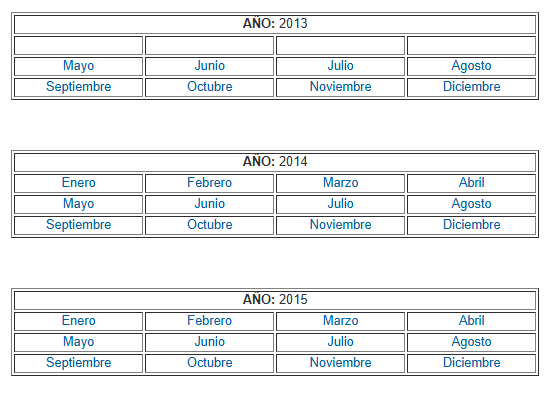

Cada tabla es un año con sus meses. Cada mes es un enlace a un `.rar` que contiene datos de cada día del mes. Así pues, se entiende que al descargar un fichero se descomprime en 30-31 xls.

Se almacenan en AWS S3 por año/mes/(resto de días del mes)

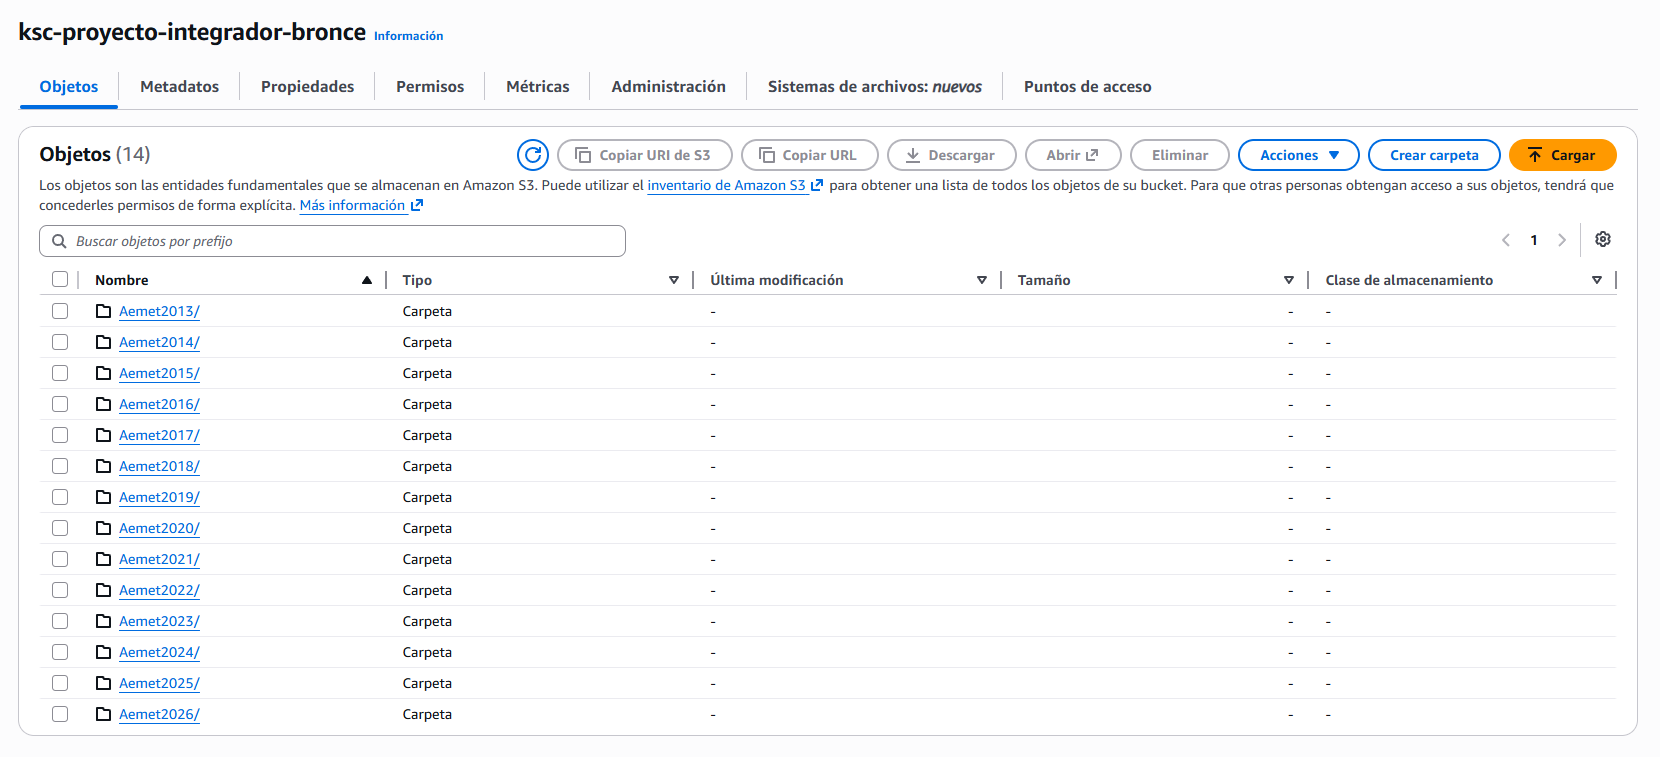

## Librería Holidays

Esta librería permite obtener los días festivos de diferentes zonas del mundo, incluidas las Comunidades Autónomas de España.

Este proceso se llevará a cabo con una función lambda, que se disparará al subir los datos de la AEMET. Su función será añadir en el csv si el día era festivo o no y guardará el objeto en la capa plata.

Además, como las funciones lambda de AWS se cobran por invocación y tiempo de ejecución, se filtrarán los datos para que sólo se aplique a los datos desde 2020 hasta 2026.

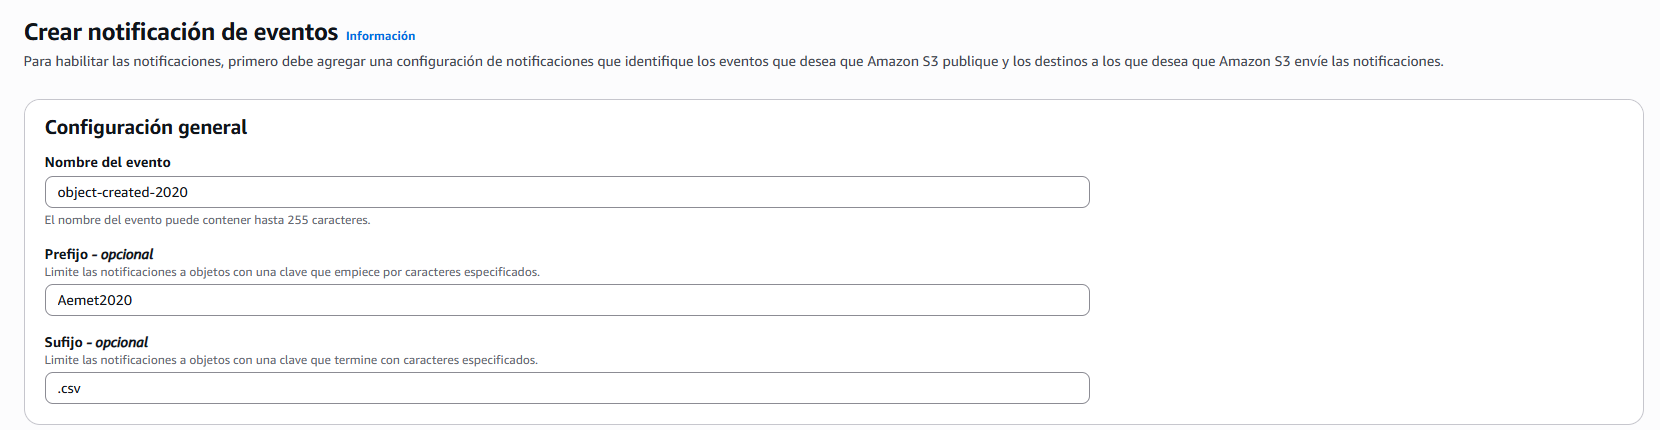
Se crea una notificación por año (Aemet2020, Aemet2021...)
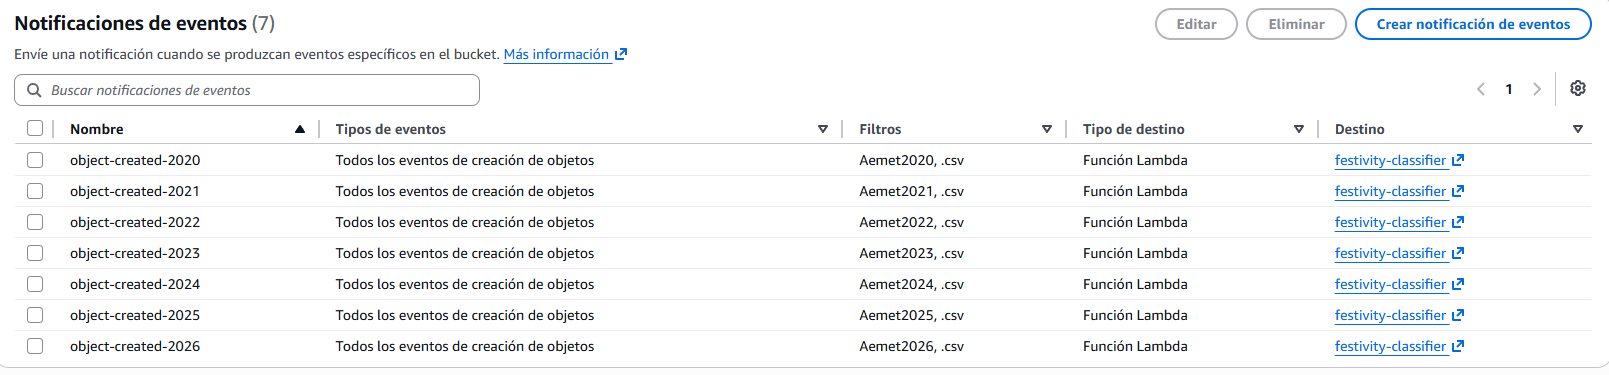

Función Lambda:

```python
import json
import urllib.parse
import boto3
import pandas as pd
import holidays
from datetime import datetime
import io

s3_client = boto3.client('s3') # lo creo fuera del handler para poder reutilizar la conexión

PROVINCIAS_CCAA = {
    # Andalucía (AN)
    'ALMERÍA': 'AN', 'CÁDIZ': 'AN', 'CÓRDOBA': 'AN', 'GRANADA': 'AN', 
    'HUELVA': 'AN', 'JAÉN': 'AN', 'MÁLAGA': 'AN', 'SEVILLA': 'AN',
    # Aragón (AR)
    'HUESCA': 'AR', 'TERUEL': 'AR', 'ZARAGOZA': 'AR',
    # Principado de Asturias (AS)
    'ASTURIAS': 'AS',
    # Canarias (CN)
    'LAS PALMAS': 'CN', 'SANTA CRUZ DE TENERIFE': 'CN',
    # Cantabria (CB)
    'CANTABRIA': 'CB',
    # Castilla y León (CL)
    'ÁVILA': 'CL', 'BURGOS': 'CL', 'LEÓN': 'CL', 'PALENCIA': 'CL', 
    'SALAMANCA': 'CL', 'SEGOVIA': 'CL', 'SORIA': 'CL', 'VALLADOLID': 'CL', 'ZAMORA': 'CL',
    # Castilla-La Mancha (CM)
    'ALBACETE': 'CM', 'CIUDAD REAL': 'CM', 'CUENCA': 'CM', 'GUADALAJARA': 'CM', 'TOLEDO': 'CM',
    # Cataluña (CT)
    'BARCELONA': 'CT', 'GIRONA': 'CT', 'GERONA': 'CT', 'LLEIDA': 'CT', 'LÉRIDA': 'CT', 'TARRAGONA': 'CT',
    # Extremadura (EX)
    'BADAJOZ': 'EX', 'CÁCERES': 'EX',
    # Galicia (GA)
    'A CORUÑA': 'GA', 'LA CORUÑA': 'GA', 'LUGO': 'GA', 'OURENSE': 'GA', 'ORENSE': 'GA', 'PONTEVEDRA': 'GA',
    # Illes Balears (IB)
    'BALEARES': 'IB', 'ILLES BALEARS': 'IB', 'ISLAS BALEARES': 'IB',
    # La Rioja (RI)
    'LA RIOJA': 'RI',
    # Comunidad de Madrid (MD)
    'MADRID': 'MD',
    # Región de Murcia (MC)
    'MURCIA': 'MC',
    # Comunidad Foral de Navarra (NC)
    'NAVARRA': 'NC',
    # País Vasco (PV)
    'ÁLAVA': 'PV', 'ARABA': 'PV', 'GUIPÚZCOA': 'PV', 'GIPUZKOA': 'PV', 'VIZCAYA': 'PV', 'BIZKAIA': 'PV',
    # Comunidad Valenciana (VC)
    'ALICANTE': 'VC', 'ALACANT': 'VC', 'CASTELLÓN': 'VC', 'CASTELLÓ': 'VC', 'VALENCIA': 'VC', 'VALÈNCIA': 'VC',
    # Ciudades Autónomas
    'CEUTA': 'CE',
    'MELILLA': 'ML'
}

BUCKET_DESTINO = "ksc-proyecto-integrador-meteo-y-vacaciones"

def lambda_handler(event, context):
    bucket = event["Records"][0]["s3"]["bucket"]["name"]
    key = urllib.parse.unquote_plus(event["Records"][0]["s3"]["object"]["key"], encoding="utf-8")

    print(f"Procesando: {key} de {bucket}")

    try:
        response = s3_client.get_object(Bucket = bucket, Key = key)
        path_splitted = key.split("/")

        year = int(path_splitted[0].replace("Aemet", ""))
        month = int(path_splitted[1])
        day = int(path_splitted[2].replace(".csv", ""))

        if year < 2020:
            print("ERROR: El fichero era anterior a 2020.")
            return
        
        df = pd.read_csv(io.BytesIO(response["Body"].read()))

        # Si no pongo la fecha en formato de pandas da errores
        current_date = pd.to_datetime(f"{year}-{month}-{day}")
        df["fecha"] = current_date

        # Separa la provincia en 2 partes (Alacant/Alicante) para quedarse con la última
        df["Provincia_Limpia"] = df["Provincia"].str.split('/').str[-1]
        df["ccaa_codigo"] = df["Provincia_Limpia"].str.strip().str.upper().map(PROVINCIAS_CCAA)
        
        df["es_festivo"] = 0

        # Es posible que deje algunas sin mapear sin darme cuenta, así que me dejo de problemas con esto
        ccaa_dataset = df["ccaa_codigo"].dropna().unique()

        for ccaa in ccaa_dataset:
            # Obtiene festivos para la comunidad autónoma específica
            country_holidays = holidays.ES(subdiv = ccaa, years = year)

            if current_date in country_holidays:
                df.loc[df['ccaa_codigo'] == ccaa, 'es_festivo'] = 1
        
        s3_client.put_object(
            Bucket = BUCKET_DESTINO,
            Key = f"{key}",
            Body = df.to_csv(index = False),
            ContentType = "text/csv"
        )
        print(f"Fichero procesado y almacenado en: {BUCKET_DESTINO}/{key}")
    except Exception as e:
        print(e)
        raise e

```

Esta función requirió de la creación de capas (Pandas y Holidays) y de asignación de memoria extra.

## Compactación de datos

Como se ha indicado, los datos almacenados en la capa bronce están divididos en ficheros `.csv` por día. Su estructura es como la siguiente:

- Aemet2020/
    - 01/
        - 01.csv
        - 02.csv
        - 03.csv
        - resto de días
    - 02/
        - 01.csv
        - 02.csv
        - 03.csv
        - resto de días
    - resto de meses
- Resto de años

Esta estructura es un problema para su posterior procesamiento, por lo que se van a compactar los datos por años. Para ello se lanzará una función manual.

*La idea inicial era lanzar una regla promada Cron desde EventBridge para que se ejecutase automáticamente cada mes o cada año, dependiendo de las necesidades. Pero para evitar esperas se creará una función Lambda que se invocará manualmente desde este código. El código de la función Lambda puede ser configurado perfectamente para una regla definida en EventBridge.*

Código de la función Lambda:

```python
import json
import pandas as pd
import awswrangler as wr

BUCKET_METEO_VACACIONES = "ksc-proyecto-integrador-meteo-y-vacaciones"
BUCKET_PLATA = "ksc-proyecto-integrador-plata"

def lambda_handler(event, context):
    year = event.get("year", "")

    if not year:
        raise ValueError("No se ha especificado el año.")

    print(f"Iniciando compactación para el año: {year}")

    try:
        target_path = f"s3://{BUCKET_METEO_VACACIONES}/Aemet{year}/"
        df_anual = wr.s3.read_csv(path = target_path)

        # Formato Hive/Spark
        target_path = f"s3://{BUCKET_PLATA}/aemet_consolidada/year={year}/aemet_historico_{year}.parquet"

        if not df_anual.empty:
            wr.s3.to_parquet(
            df = df_anual,
            path = target_path,
            index = False
        )
        
    except Exception as e:
        print(ROR: {e}")
        raise e




```

In [12]:
client = boto3.client("lambda", region_name = "us-east-1")

try:
    for year in range(2020, 2027):
        year_message = {
            "year": year
        }

        client.invoke(
            FunctionName = "compact-data",
            InvocationType = "RequestResponse",
            Payload = json.dumps(year_message).encode("utf-8")
        )
except Exception as e:
    print(f"ERROR: {e}")

## Unificación y compactación completa de datos

Una vez que tenemos los datos de días con la meteorología y los datos de generación necesitamos compactarlos en un mismo dataset para poder operar de manera eficiente con ello. Aunque las transformaciones en los datos de generación las he considerado como de capa plata, esta unificación de todos los datos también la consideraré como tal, pues aún no se han realizado procesos de limpieza de datos como tal, simplemente se ha realizado un enriquecimiento.

Como los datos que he enriquecido son los de los años 2020 en adelante, estos serán los que utilice en este punto.

In [2]:
BUCKET_PLATA = "ksc-proyecto-integrador-plata"

dfs_energy = []
dfs_meteo_holidays = []

for year in range(2020, 2027):
    energy_object_path = f"s3://{BUCKET_PLATA}/energia_consolidada/year={year}"
    dfs_energy.append(wr.s3.read_parquet(path = energy_object_path))

    meteo_holidays_object_path = f"s3://{BUCKET_PLATA}/aemet_consolidada/year={year}"
    dfs_meteo_holidays.append(wr.s3.read_parquet(path = meteo_holidays_object_path))

df_energy_full = pd.concat(dfs_energy)
df_aemet_full = pd.concat(dfs_meteo_holidays)

df_energy_full["fecha"] = pd.to_datetime(df_energy_full["fecha"], utc = True).dt.tz_localize(None).dt.normalize()
df_aemet_full["fecha"] = pd.to_datetime(df_aemet_full["fecha"], utc = True).dt.tz_localize(None).dt.normalize()

In [3]:
df_full = pd.merge(df_aemet_full, df_energy_full, on = "fecha", how = "inner")
df_full.head()

,Estación,Provincia,Temperatura_máxima__ºC_,Temperatura_mínima__ºC_,Temperatura_media__ºC_,Racha__km/h_,Velocidad_máxima__km/h_,Precipitación_00-24h__mm_,Precipitación_00-06h__mm_,Precipitación_06-12h__mm_,...,hidraulica_fluyente_mwh,hidraulica_embalse_mwh,maritima_mwh,nuclear_mwh,otras_tecnologias_mwh,otras_renovables_mwh,solar_fotovoltaica_mwh,residuos_mwh,eolica_marina_mwh,eolica_terrestre_mwh
0,Estaca de Bares,A Coruña,20.3 (13:50),14.9 (01:20),17.6,46 (03:10),40 (03:10),0.0,0.0,0.0,...,32022.0,74460.0,0.0,95104.0,1239.0,2465.0,67691.0,5141.0,0.0,46137.0
1,Ferrol,A Coruña,24.4 (14:40),15.6 (04:10),20.0,32 (17:00),23 (16:20),0.0,0.0,0.0,...,32022.0,74460.0,0.0,95104.0,1239.0,2465.0,67691.0,5141.0,0.0,46137.0
2,As Pontes,A Coruña,29.1 (15:30),13.8 (07:20),21.5,<NA>,<NA>,0.0,0.0,0.0,...,32022.0,74460.0,0.0,95104.0,1239.0,2465.0,67691.0,5141.0,0.0,46137.0
3,A Coruña,A Coruña,22.8 (12:50),15.8 (04:10),19.3,39 (02:00),22 (02:00),0.0,0.0,0.0,...,32022.0,74460.0,0.0,95104.0,1239.0,2465.0,67691.0,5141.0,0.0,46137.0
4,A Coruña Aeropuerto,A Coruña,22.1 (12:30),15.2 (06:40),18.7,37 (02:20),25 (16:50),0.0,0.0,0.0,...,32022.0,74460.0,0.0,95104.0,1239.0,2465.0,67691.0,5141.0,0.0,46137.0


In [40]:
# Una vez unidos por la clave podemos volver a tener la fecha como tipo Date
df_full["fecha"] = pd.to_datetime(df_full["fecha"]).dt.date
df_full_copy = df_full.copy()

### Limpieza de datos

Como podemos ver tanto el `head()`de arriba como en el `describe()` de abajo, existen varias columnas que deben de ser tratadas para poder disponer de datos de calidad real.

In [28]:
df_full.describe()

,Temperatura_media__ºC_,Precipitación_00-24h__mm_,Precipitación_00-06h__mm_,Precipitación_06-12h__mm_,Precipitación_12-18h__mm_,Precipitación_18-24h__mm_,fecha,es_festivo,biomasa_mwh,carbon_marron_lignito_mwh,...,hidraulica_fluyente_mwh,hidraulica_embalse_mwh,maritima_mwh,nuclear_mwh,otras_tecnologias_mwh,otras_renovables_mwh,solar_fotovoltaica_mwh,residuos_mwh,eolica_marina_mwh,eolica_terrestre_mwh
count,497686.000000,486948.000000,492093.000000,490623.000000,491575.000000,492751.000000,524881,524881.0,524881.000000,524881.0,...,524881.000000,524881.000000,524881.0,524881.00000,524881.000000,524881.000000,524881.000000,524881.000000,524881.0,5.248810e+05
mean,9.767342,3.368206,0.776317,0.892675,0.903023,0.798447,2026-02-13 22:23:59.846365,0.026566,36082.161023,0.0,...,120027.486017,357751.073017,0.0,579690.60123,470.337010,6118.421722,414250.807303,14355.257965,0.0,8.184246e+05
min,-14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2025-12-31 00:00:00,0.0,1612.000000,0.0,...,4272.000000,9400.000000,0.0,28464.00000,0.000000,272.000000,144.000000,848.000000,0.0,8.520000e+03
25%,6.900000,0.000000,0.000000,0.000000,0.000000,0.000000,2026-01-22 00:00:00,0.0,31704.000000,0.0,...,105724.000000,268708.000000,0.0,538156.00000,356.000000,5796.000000,254412.000000,11904.000000,0.0,4.502160e+05
50%,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2026-02-14 00:00:00,0.0,38344.000000,0.0,...,126784.000000,362352.000000,0.0,587716.00000,500.000000,6136.000000,402752.000000,14768.000000,0.0,8.582400e+05
75%,12.900000,2.600000,0.000000,0.100000,0.200000,0.200000,2026-03-09 00:00:00,0.0,41004.000000,0.0,...,138688.000000,473140.000000,0.0,682016.00000,664.000000,6616.000000,570328.000000,16700.000000,0.0,1.117800e+06
max,26.500000,581.500000,151.700000,133.300000,151.100000,145.400000,2026-03-31 00:00:00,1.0,46760.000000,0.0,...,156428.000000,577304.000000,0.0,683416.00000,972.000000,7176.000000,847064.000000,20348.000000,0.0,1.716292e+06
std,4.602619,8.915143,2.949548,3.249500,2.943985,2.775037,NaN,0.160811,7773.234896,0.0,...,25132.580695,127566.146233,0.0,102974.47590,274.012818,791.285618,199913.644440,3208.506305,0.0,4.088148e+05


En los datos de arriba podemos ver varios problemas:
- Existen valores extremos en las precipitaciones (media de `3.368` y valor máximo de `581.5`, por ejemplo) y la información que representa cada columna es redundante (hay una columna para las precipitaciones acumuladas durante 24 horas, pero tenemos 4 divisiones cada 4 horas).
- Existen columnas de generación de energía que no contienen datos. Aunque esto no es un error porque España no utiliza estas fuentes para generar energía, pueden generar problemas en el modelo, además de ocupar un tamaño en memoria significativo sin aportar nada a cambio.
- Existen errores de formato en algunas columnas:
    - Temperatura Máxima y Temperatura Mínima con el formato: 10.5 (15:00) -> refiriéndose a la medida y a la hora
    - Rachas de viento por hora y rachas máximas con el formato: 50 (1:00) -> Similar al anterior punto.

La siguiente matriz de correlación muestra también esta falta de valores en aquellas columnas en las que España no tiene ningún tipo de generación. Estas columnas serán eliminadas por considerarse redundantes e inútiles.

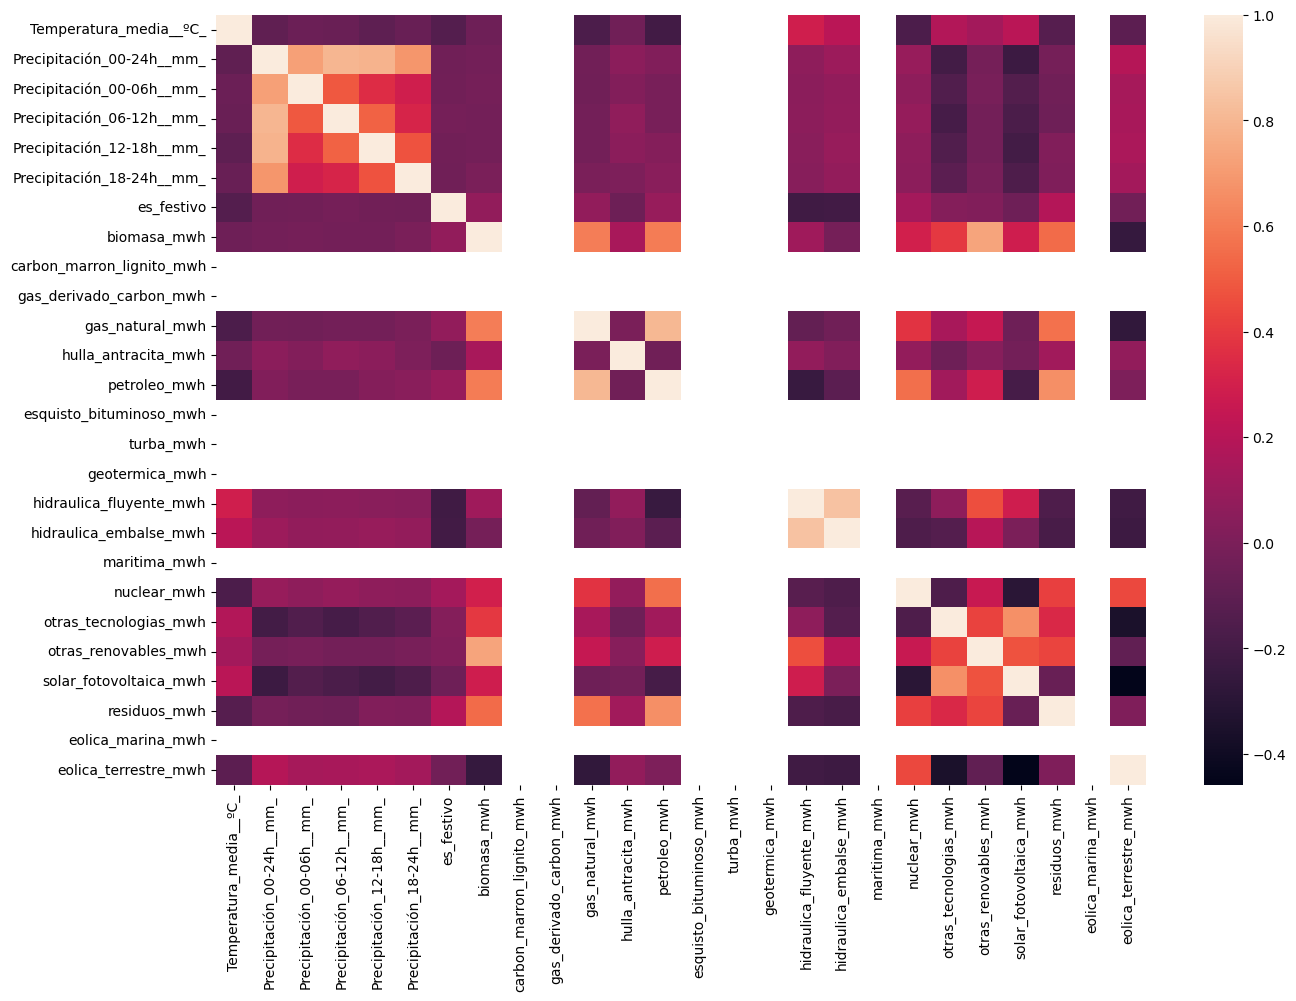

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
sns.heatmap(df_full.corr(numeric_only = True))
plt.show()

#### Eliminación de valores redundantes o poco útiles

En esta sección se eliminarán todas aquellas columnas que no aportan información extra, presentan multicolinealidad o están vacías.

In [80]:
print(f"Registros, dimensiones pre-limpieza: {df_full_copy.shape}")

Registros, dimensiones pre-limpieza: (1690840, 36)


In [7]:
def clean_value_hour_format(value):
    if isinstance(value, str):
        value, _ = splitted_value = value.split(" ")
    return float(value)

In [41]:
# Conversiones de datos

# Los datos de viento nulos pasan a ser 0
df_full_copy["Racha__km/h_"] = df_full_copy["Racha__km/h_"].fillna(0)
df_full_copy["Velocidad_máxima__km/h_"] = df_full_copy["Velocidad_máxima__km/h_"].fillna(0)

# Conversión del formato de 10.5 (10:30)
df_full_copy["Racha__km/h_"] = df_full_copy["Racha__km/h_"].apply(clean_value_hour_format)
df_full_copy["Velocidad_máxima__km/h_"] = df_full_copy["Velocidad_máxima__km/h_"].apply(clean_value_hour_format)

# Media viento
df_full_copy["Viento_media_km/h"] = df_full_copy[["Racha__km/h_", "Velocidad_máxima__km/h_"]].mean(axis = 1)

In [42]:
# Columnas sin datos
columnas_eliminar = ["carbon_marron_lignito_mwh", "gas_derivado_carbon_mwh", "esquisto_bituminoso_mwh", "geotermica_mwh", "turba_mwh", "maritima_mwh", "eolica_marina_mwh"]

# Columnas precipitaciones por horas
columnas_eliminar.extend(["Precipitación_00-06h__mm_", "Precipitación_06-12h__mm_", "Precipitación_12-18h__mm_",	"Precipitación_18-24h__mm_"])

# Columnas de temperatura media y temperatura minima
columnas_eliminar.extend(["Temperatura_máxima__ºC_", "Temperatura_mínima__ºC_"])

# Columnas de viento
columnas_eliminar.extend(["Racha__km/h_", "Velocidad_máxima__km/h_"])

df_full_copy.drop(columns = columnas_eliminar, inplace = True)

In [21]:
print(f"Registros, dimensiones post-limpieza: {df_full_copy.shape}")

Registros, dimensiones post-limpieza: (1690840, 22)


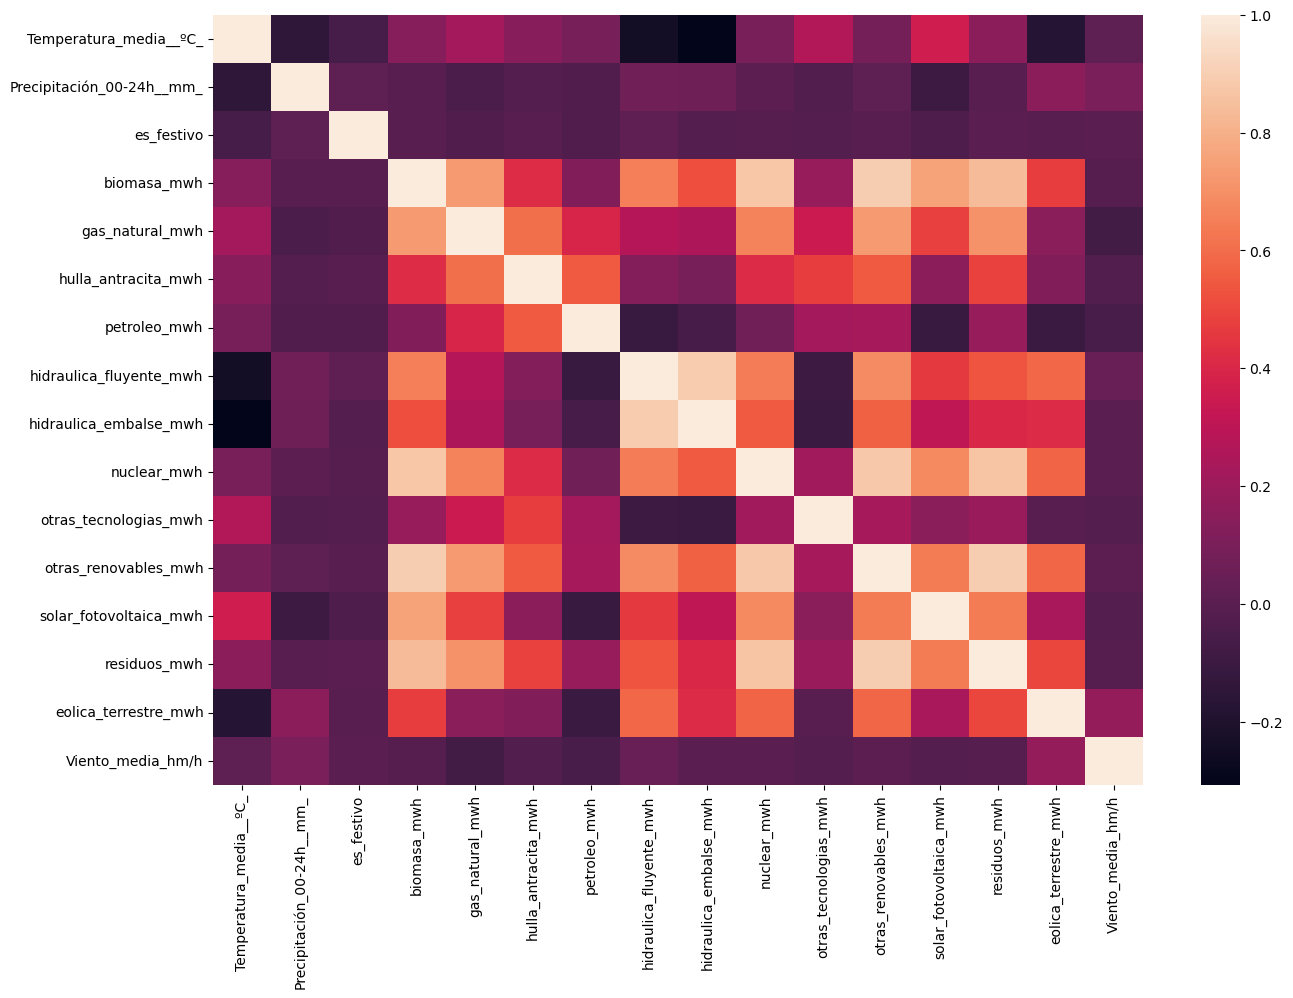

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
sns.heatmap(df_full_copy.corr(numeric_only = True))
plt.show()

Como vemos, la matriz de correlación se ve muchísimo más limpia ahora, sin columnas faltantes y ya se pueden empezar a ver comportamientos en ella (la generación solar fotovoltaica sube un poco cuando hay más temperatura -más horas de sol generalmente- o las hidraúlicas bajan cuando hay la temperatura media se eleva también -como antes, más sol, menos lluvias-...)

Sin embargo nos quedan unos cuantos valores extremos limpiar o adaptar para que un modelo pueda funcionar con estos datos.

In [28]:
# Al hacer la limpieza los valores se muestran en notación científica, así que los ponemos en formato de dos decimales sólo para este describe
df_full_copy.describe().apply(lambda s: s.apply(lambda x: f'{x:.2f}'))

,Temperatura_media__ºC_,Precipitación_00-24h__mm_,es_festivo,biomasa_mwh,gas_natural_mwh,hulla_antracita_mwh,petroleo_mwh,hidraulica_fluyente_mwh,hidraulica_embalse_mwh,nuclear_mwh,otras_tecnologias_mwh,otras_renovables_mwh,solar_fotovoltaica_mwh,residuos_mwh,eolica_terrestre_mwh,Viento_media_km/h
count,1618374.00,1603006.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00
mean,15.81,1.82,0.03,29016.48,455291.88,28737.48,4288.52,65179.69,168476.91,433547.01,1374.02,5638.11,340027.48,15656.45,476605.19,22.61
std,7.23,6.36,0.18,13900.80,305318.18,27894.57,2763.96,40460.34,127520.83,221250.56,1291.16,2476.07,267727.39,7437.72,364890.34,15.09
min,-16.10,0.00,0.00,492.00,3478.00,0.00,32.00,1070.00,1333.00,680.00,0.00,96.00,10.00,218.00,6342.00,0.00
25%,10.40,0.00,0.00,12334.00,212245.00,10590.00,2576.00,27026.00,65763.00,167392.00,664.00,2530.00,87101.00,7193.00,183180.00,14.50
50%,15.70,0.00,0.00,35028.00,392676.00,23808.00,3707.00,56992.00,126392.00,489232.00,1040.00,6580.00,295336.00,17332.00,379144.00,22.50
75%,21.30,0.20,0.00,40736.00,621192.00,33396.00,5083.00,100596.00,243680.00,658772.00,1411.00,7604.00,549912.00,21820.00,687488.00,31.00
max,40.20,758.00,1.00,54132.00,1630056.00,171352.00,19288.00,159380.00,577304.00,685048.00,5704.00,10944.00,1047012.00,30380.00,1746940.00,199.50


En las características estadísticas podemos detectar varios valores extraños:

- **Precipitaciones**: El valor medio es de `1.82` mm, pero el valor máximo es de `758` mm. Es muy posible que esto se pueda deber o bien a un error tipográfico o a un evento extraño y muy poco frecuente (como la de la DANA de Valencia de 2024). En cualquier caso, al ser un dato tan extraordinario, podría confundir a un modelo al no ser la norma general.
- **Viento medio**: El valor medio es de `22.6` km/h, pero el valor máximo es de `199.50` km/h. De nuevo, probablemente se pueda deber a un caso aislado y por lo tanto puede evitar una buena generalización del modelo.
- **Solar fotovoltaica**: El mínimo de la generación solar fotovoltaica es de `10` MWh. Esto es muy poco para un país como España. Podemos suponer que se debe a un fallo en la lectura o la carga de datos en la API de entso-e.
- **Hulla/antracita y otras tecnologías**: Presentan mínimos de `0.0` MWh. En el caso de la hulla/antracita, la desviación estándar de `27894.57` (casi lo mismo que la media), lo que indica un cambio demasiado drástico en los datos. Es posible que esto sea cierto; el sistema de electricidad español ha ido dejando los combustibles fósiles por más energía renovable y esto podría explicarlo, pero no dejan de ser valores extremos que podrían confundir a un modelo.

A estas conclusiones hay que hacerles el apunte del apagón de 2025. Aunque haya sido un día, hay generaciones energéticas que no pueden parar de golpe y deben autoprotegerse (como la nuclear) que pueden tardar días en volver a funcionar con normalidad, los datos podrían no haber transmitido bien ese día, etc. Para este trabajo sería hilar muy fino, pero en una exloración más seria sería conveniente tenerlo en cuenta.

#### Visualización de outliers con boxplot

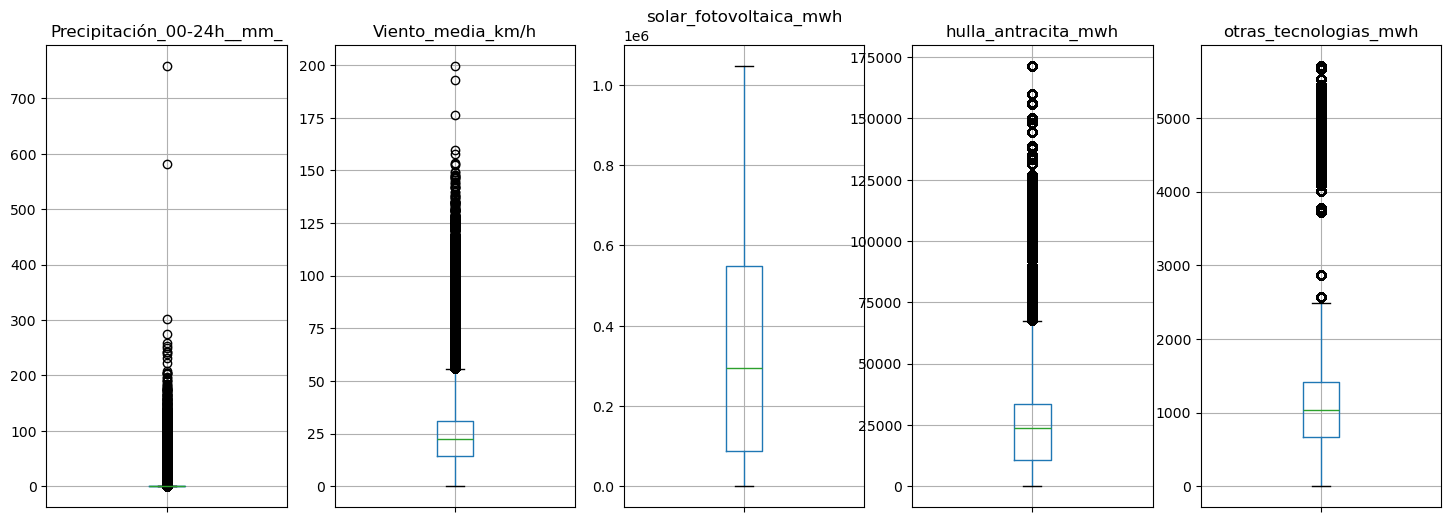

In [43]:
def create_boxplots(outliers_cols):
    fig, axes = plt.subplots(nrows = 1, ncols = len(outliers_cols), figsize = (18, 6))
    
    for i, col in enumerate(outliers_cols):
        df_full_copy.boxplot(column = col, ax = axes[i])
    
        axes[i].set_title(col)
        axes[i].set_xticklabels([""])

outliers_cols = ["Precipitación_00-24h__mm_", "Viento_media_km/h", "solar_fotovoltaica_mwh", "hulla_antracita_mwh", "otras_tecnologias_mwh"]
create_boxplots(outliers_cols)

- **Precipitaciones**: Observamos como la caja no existe como tal. España es relativamente seco, pero con lluvia. Hay que tener en cuenta que hay zonas en las que unos cuantos días de lluvia pueden presentar variaciones en la media y esto no quiere decir necesariamente que los datos sean incorrectos, pero pueden desestabilizar un modelo. Por ello vamos a cortarlos en torno a los `250 mm`, que es donde los datos empiezan a dispersarse claramente.
- **Viento medio**: La distribución es muy similar a la de la hulla/antracita, pero por razones distintas. El viento no es estable y no siempre sopla de la misma manera, pero sí es progresivo. Es por ello que los outliers están muy próximos entre sí. La media se sitúa en torno a los `25 km/h` en todo el país, lo que habla de la suavizaz del clima, pero existen datos altos más allá de los `100 km/h`. De todos modos, debemos tener en cuenta que los aerogeneradores tienen una velocidad de giro máxima por seguridad, lo que se traduce en que la creencia de que `+ viento = + energía` no siempre es cierta. Este freno de seguridad depende del aerogenerador, pero el valor medio es de `25 m/s ≈ 90 km/h`. ([Fuente](https://researchhubs.com/post/engineering/wind-energy/power-output-variation-with-wind-speed.html))
- **Solar fotovoltaica**: El boxplot no presenta outliers (lo que son buenas noticias). De hecho, que no los presente puede hablarnos sobre el ciclo de estaciones de la propia Tierra y el clima suave de España: el bigote inferior baja hasta esos `10.0` MWh que se habían observado antes y el superior sube por encima de los `100000` MWh sin presentar ningún outlier. Esto quiere decir que el patrón se repite y que es normal. Por el momento esta columna no será tratada, pero será vigilada a la hora de entrenar un modelo y su comportamiento.
- **Hulla/antracita**: La caja está muy abajo y los valores extremos están por arriba, pero muy cercanos entre sí. Con una rápida búsqueda en Google podemos confirmar que, en efecto, entre 2018 y 2023 España comenzó a apagar centrales térmicas de carbón. Es por ello que estos valores están muy pegados entre sí, pero ya no cuadran con la media (la caja). Para acabar con este punto, en 2025 se apagó la última central de carbón española, por lo que podemos eliminar esta columna por no aportar información predictora relevante. ([Fuente](https://es.wikipedia.org/wiki/Cierre_de_las_centrales_t%C3%A9rmicas_de_carb%C3%B3n_en_Espa%C3%B1a))
- **Otras tecnologías**: No se puede decir demasiado de esta columna, ya que ni siquiera la API de entso-e da alguna explicación. Seguramente incluya muchas formas de energía menores que no tienen tanta relevancia como para tener su propia columna. Vemos que los outliers son muy fuertes, pero no podemos sacar más conclusiones. Ante la duda, será eliminada (junto con `otras_renovables_mwh` por consistencia). 

Tenemos suficientes datos (> 1 millón y medio), por lo que podemos aplicar un corte en lugar de una imputación y así mantenemos datos fieles a la realidad.

Registros pre-tratamiento de outliers: 1690840
Registros post-tratamiento de outliers: 1601759


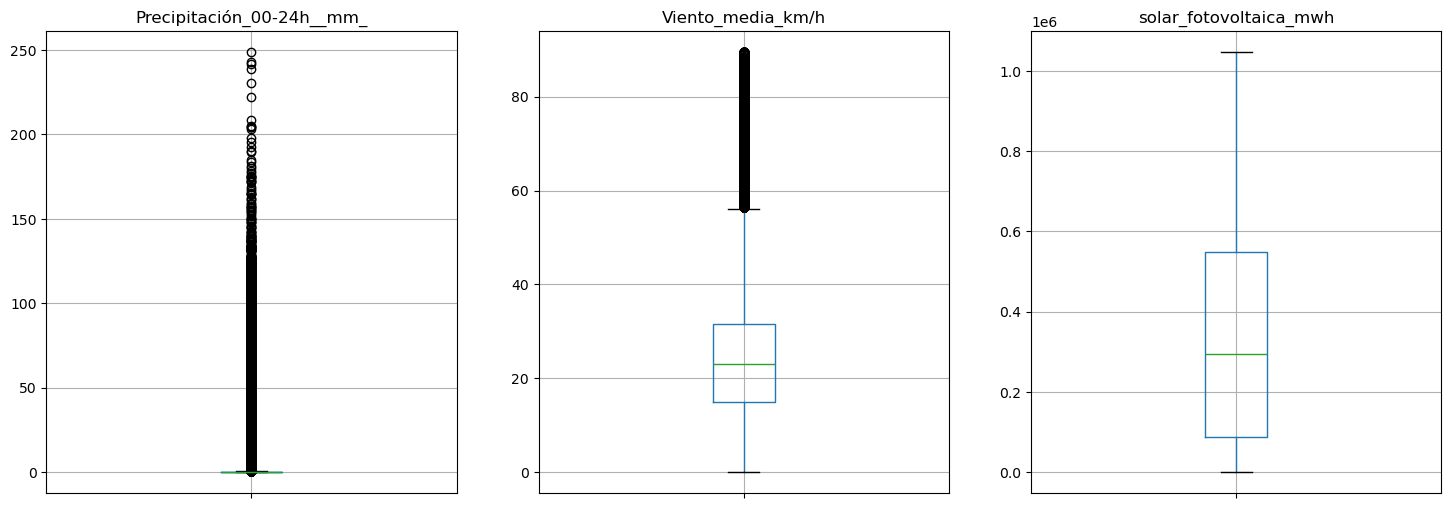

In [44]:
# Tratamiento de outliers descritos
print(f"Registros pre-tratamiento de outliers: {df_full_copy.shape[0]}")

# Precipitaciones solo menores a 250 mm
df_full_copy = df_full_copy[df_full_copy["Precipitación_00-24h__mm_"] < 250]

# Viento medio solo menor a 90 km/h
df_full_copy = df_full_copy[df_full_copy["Viento_media_km/h"] < 90]

df_full_copy.drop(columns = ["hulla_antracita_mwh", "otras_tecnologias_mwh", "otras_renovables_mwh"])

print(f"Registros post-tratamiento de outliers: {df_full_copy.shape[0]}")

outliers_cols = ["Precipitación_00-24h__mm_", "Viento_media_km/h", "solar_fotovoltaica_mwh"]
create_boxplots(outliers_cols)

Han sido eliminados cerca de `90000` registros, pero eso apenas representa un `5%` de los datos.

En cuanto a los nuevos boxplots, aunque presenten los outliers, creo que estos representan la realidad del clima y pueden ser importantes para predecir la generación en un futuro:

- Las precipitaciones presentan muchos outliers, pero mientras que hay sitios muy secos (Cabo de Gata o Almería apenas reciben `150 mm` de precipitaciones al año), existen otros mucho más húmedos (Asturias con más de `900 mm` de media). Esto puede ir contra del pensamiento de cortar estos datos por encima de los `250 mm`, pero no se debe olvidar de que estamos hablando de medias nacionales y son dos climas completamente distintos. Para más precisión sería mejor desarrollar modelos específicos por clima.
- La media del viento se ve contenida y con esos puntos extremos solapándose. Al igual que en el anterior punto, existen zonas con muchísimo viento (cualquier lugar de montaña o costa) y otras con mucho menos (ciudades de interior como Madrid).